In [21]:
from representations import load_model, load_examples, extract_generated, check_correctness
from curvature_analysis import (
    compute_curvature,
    analyze_model_curvature,
    plot_heatmap,
    plot_mean_curvature_by_layer,
    plot_correct_vs_incorrect,
    plot_correct_vs_incorrect_split,
    plot_curvature_profile,
    plot_turtle,
    plot_layer_curvature_heatmap,
    plot_mean_curvature_by_stride,
)

In [22]:
MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
DATA_FILE = "/home/jay/repos/llm-jepa/datasets/synth_test.jsonl"
BASE_MODEL = "meta-llama/Llama-3.2-1B-Instruct"
N_EXAMPLES = 200
MAX_NEW_TOKENS = 128
STRIDES = (1, 2, 4, 8, 16)

In [23]:
examples = load_examples(DATA_FILE, BASE_MODEL, n=N_EXAMPLES)
print(f"Loaded {len(examples)} examples")

Loaded 200 examples


In [24]:
all_results = {}
for label, model_path in MODELS.items():
    all_results[label] = analyze_model_curvature(
        model_path, BASE_MODEL, examples, DATA_FILE, MAX_NEW_TOKENS,
        strides=STRIDES,
    )


Loading /home/jay/repos/llm-jepa/output-exp1-regular...


Extracting: 100%|██████████| 200/200 [00:46<00:00,  4.31it/s]



Loading /home/jay/repos/llm-jepa/output-exp1-stp...


Extracting: 100%|██████████| 200/200 [00:34<00:00,  5.86it/s]


In [25]:
import numpy as np

for label, results in all_results.items():
    correct = sum(1 for r in results if r["correct"])
    total = len(results)
    for s in STRIDES:
        valid = [r for r in results if s in r["curvature"]]
        if valid:
            mean_curv = np.mean([r["curvature"][s].mean() for r in valid])
            print(f"{label} stride={s}: mean curvature {mean_curv:.4f} (n={len(valid)})")
    print(f"{label}: {correct}/{total} correct\n")

NTP stride=1: mean curvature 1.4166 (n=199)
NTP stride=2: mean curvature 1.4403 (n=199)
NTP stride=4: mean curvature 1.4883 (n=191)
NTP stride=8: mean curvature 1.4637 (n=97)
NTP stride=16: mean curvature 1.1913 (n=12)
NTP: 6/199 correct

STP stride=1: mean curvature 1.4109 (n=199)
STP stride=2: mean curvature 1.4479 (n=199)
STP stride=4: mean curvature 1.5017 (n=189)
STP stride=8: mean curvature 1.4449 (n=83)
STP: 29/199 correct



In [26]:
for label, results in all_results.items():
    print(f"\n--- {label} ---")
    for r in results[:3]:
        print(f"  {'OK' if r['correct'] else 'WRONG'}: {repr(r['generated_text'][:80])}")


--- NTP ---
  WRONG: "lines not having the string 'dog' followed by a number, 3 or more times. Regex p"
  WRONG: '(\\b.*)([AEIOUaeiou])*|((.)*)*)*'
  WRONG: '((([0-9])|(.)).*[AEIOUaeiou].*.*.*'

--- STP ---
  WRONG: '~((dog.*[0-9].*)&((dog.*[0-9].*){3,})'
  WRONG: '(\\b.*)([AEIOUaeiou])*|((.*))*)'
  WRONG: '(\\b([0-9])|(.)\\b)*([AEIOUaeiou]).'


interpretaion: range of mean curvurutre is 0-2. 
0 means it's perfectly straight
1 means it's orthogonal, no correlation
2 means it's full reversal.

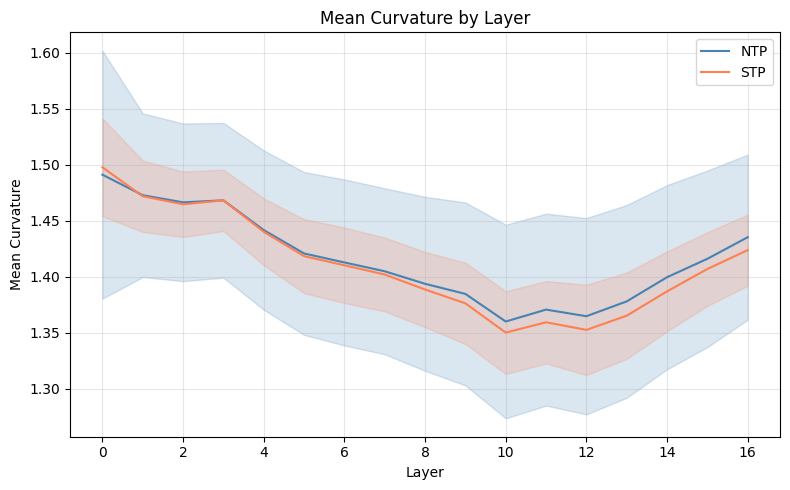

In [27]:
labels = list(all_results.keys())
results_list = list(all_results.values())

plot_mean_curvature_by_layer(results_list, labels)

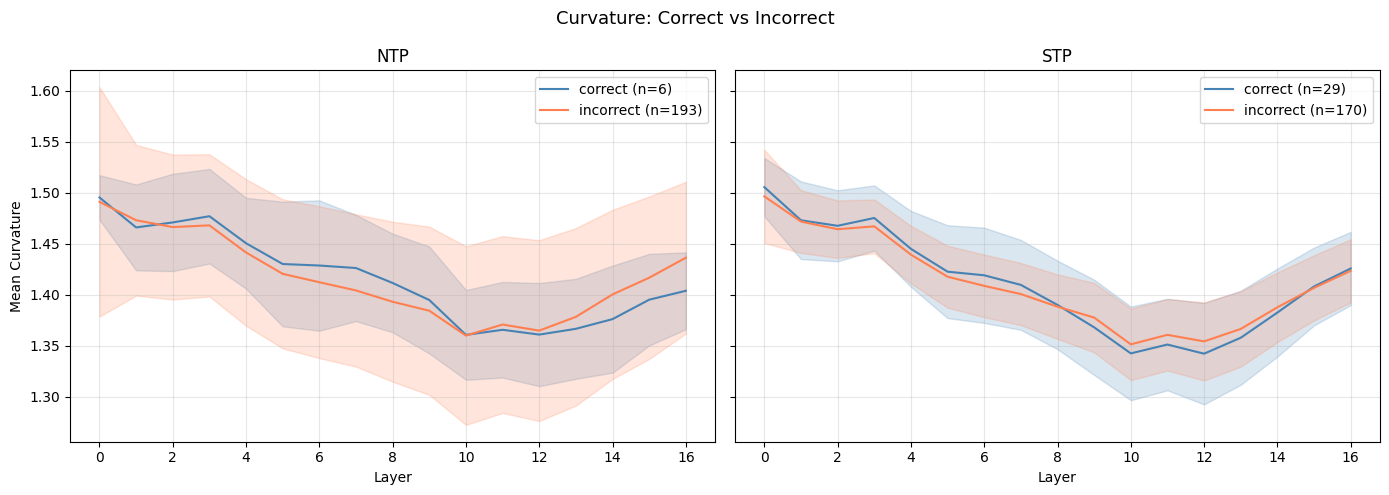

In [28]:
plot_correct_vs_incorrect(results_list, labels)

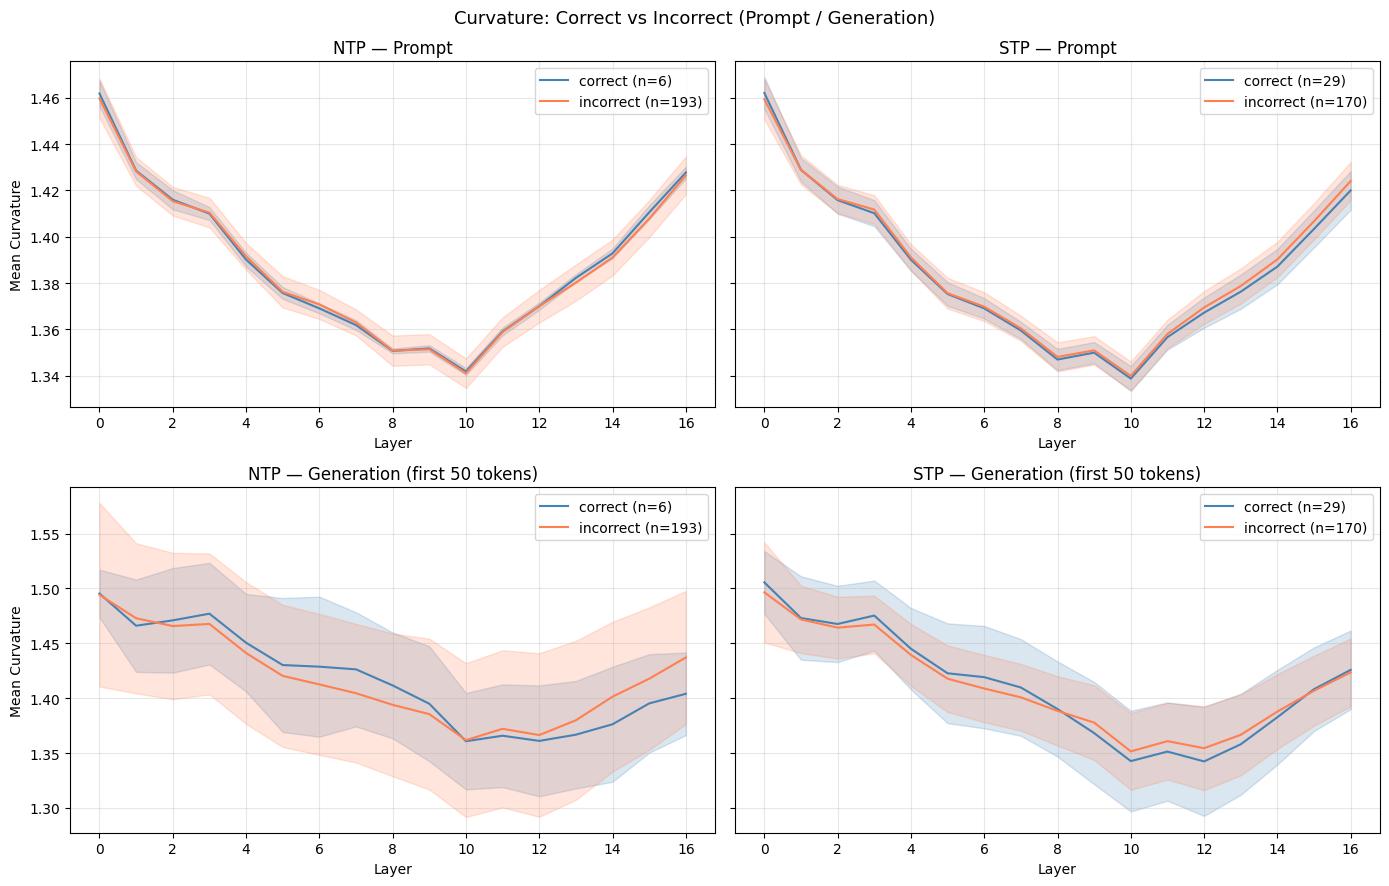

In [33]:
plot_correct_vs_incorrect_split(results_list, labels, max_gen_tokens=50)

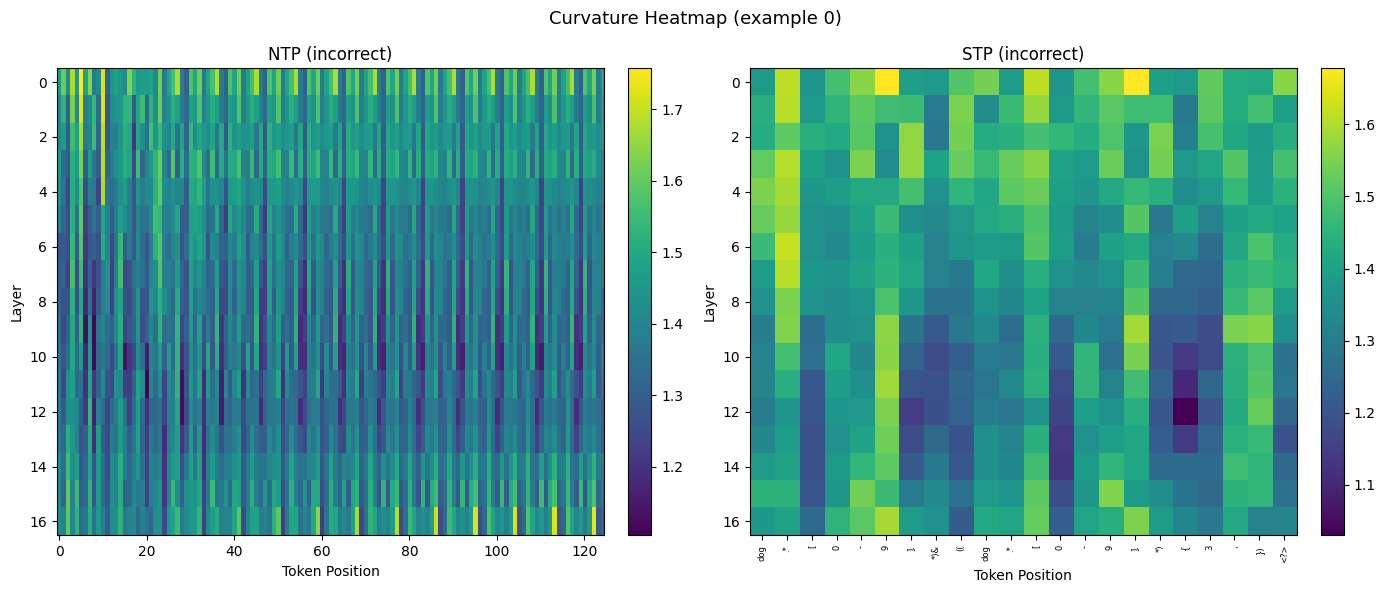

In [10]:
plot_heatmap(results_list, labels, example_idx=0)

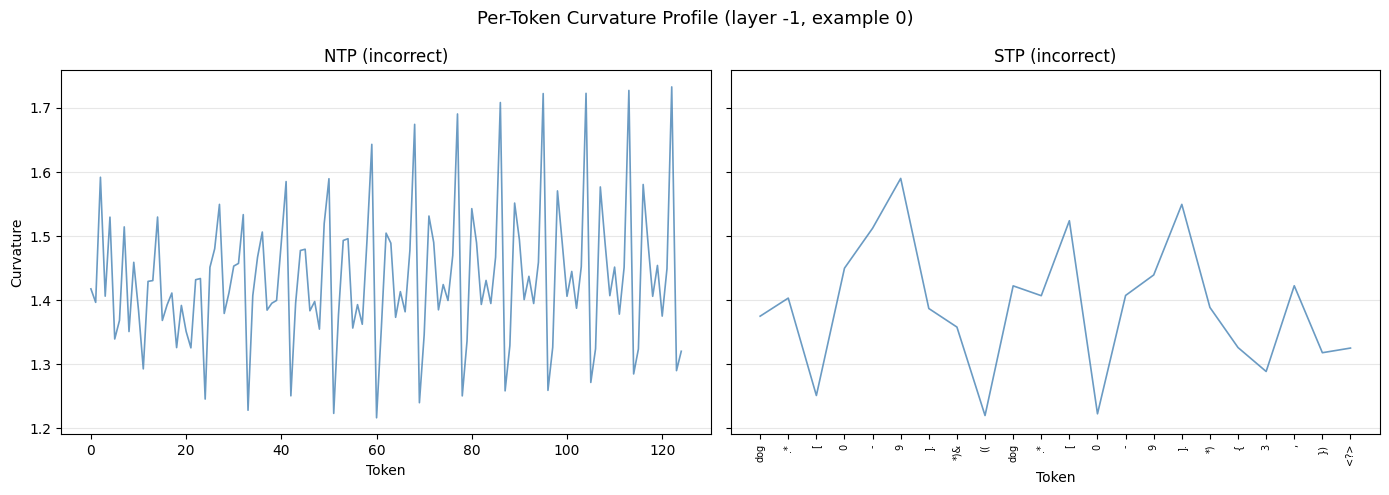

In [11]:
plot_curvature_profile(results_list, labels, example_idx=0, layer=-1)


--- Stride 1 ---


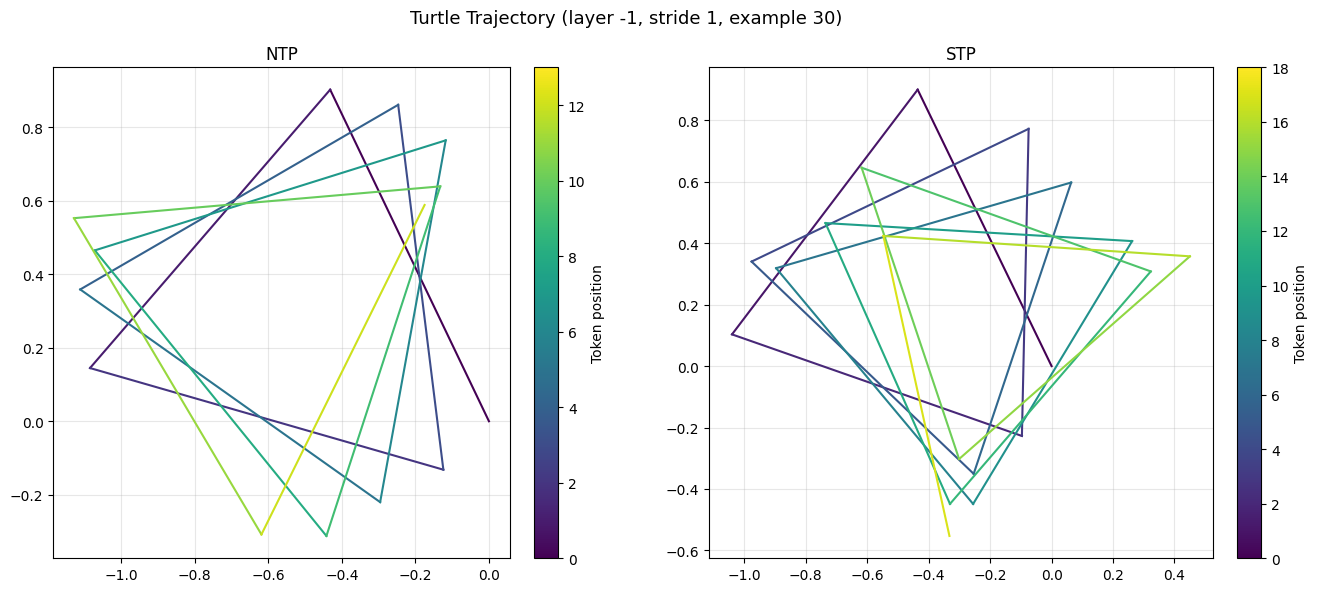


--- Stride 2 ---


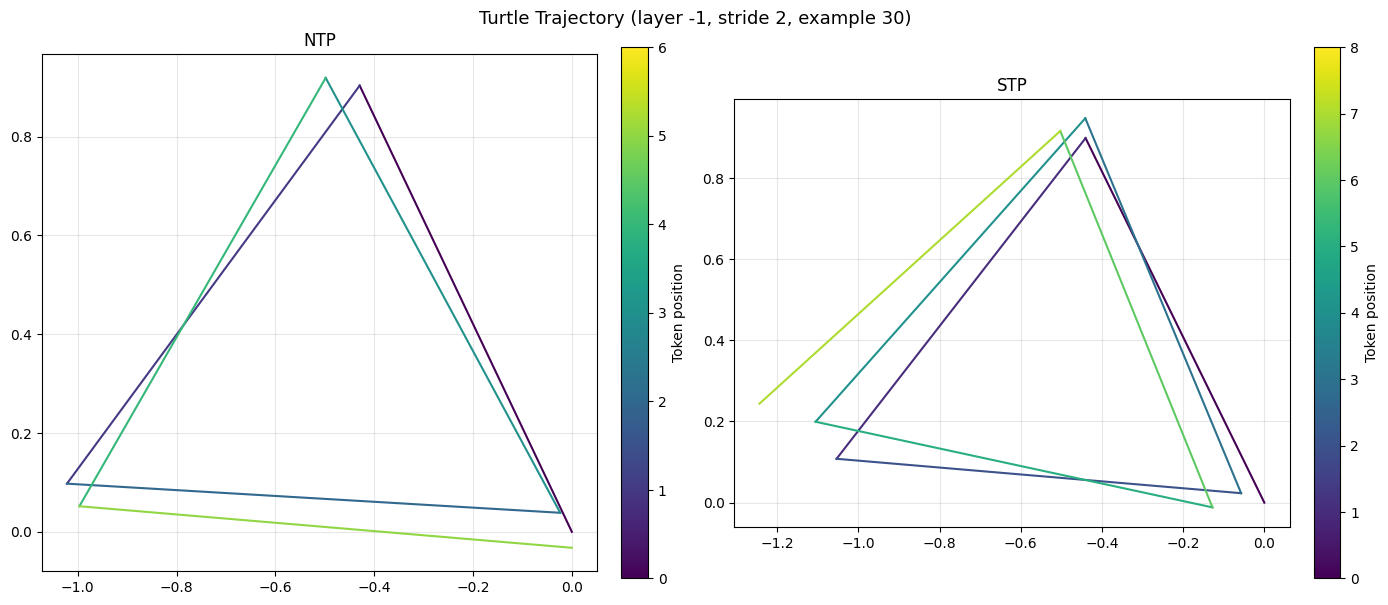


--- Stride 4 ---


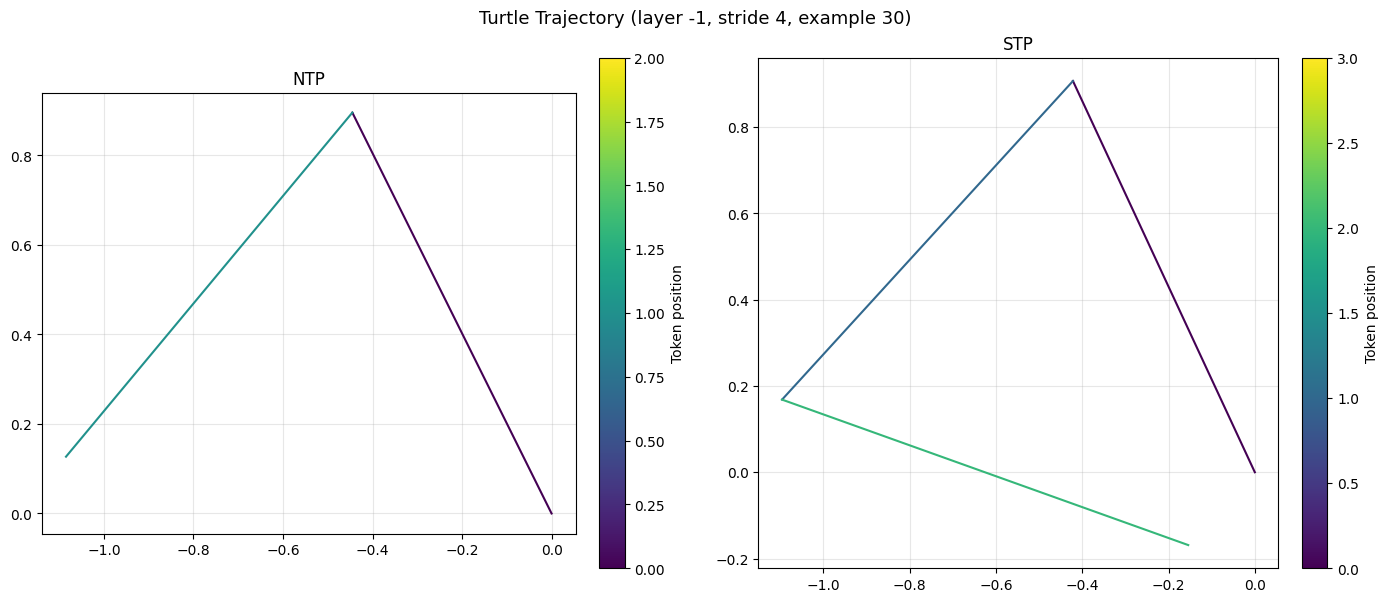


--- Stride 8 ---


KeyError: 8

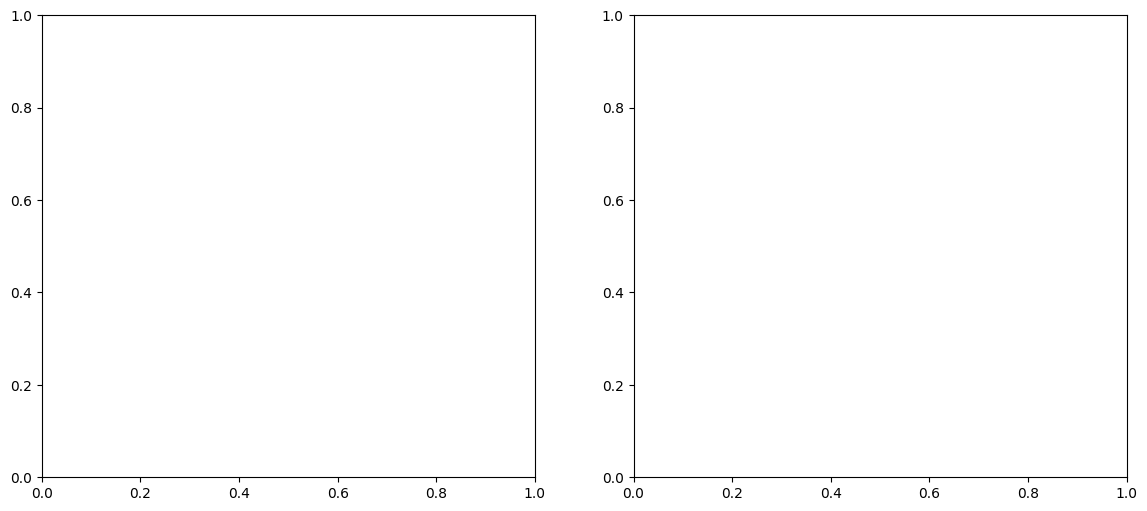

In [40]:
for s in STRIDES:
    print(f"\n--- Stride {s} ---")
    plot_turtle(results_list, labels, example_idx=30, layer=-1, stride=s)

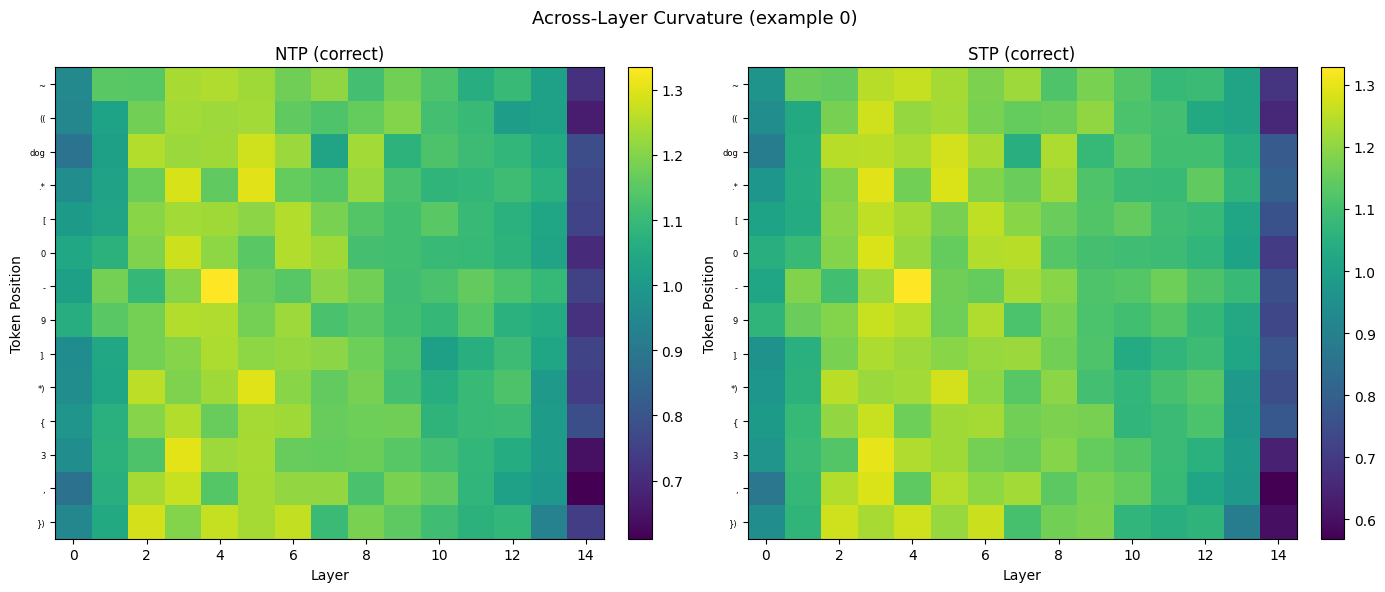

In [16]:
plot_layer_curvature_heatmap(results_list, labels, example_idx=0)

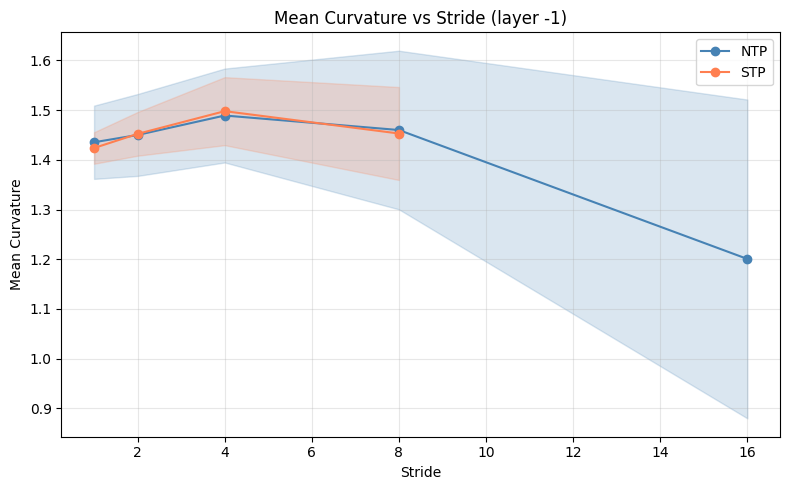

In [13]:
plot_mean_curvature_by_stride(results_list, labels, STRIDES, layer=-1)